In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pyharm.ana_results as an
from matplotlib.colors import Normalize

In [3]:
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 10,        # 默认字体大小
    "axes.labelsize": 10,   # 轴标签字体大小
    "legend.fontsize": 10,  # 图例字体大小
    "mathtext.fontset": "stix",  # 数学字体设置为 STIX，这个与 Times New Roman 很接近
})

In [4]:
ana_file_a05e00 = "/home/zhangzelin/projects/kharma-data-sync/20241216_cuda_sane_a05000_288-192-128_6-12_rout1000_min020_gamma13/eht_out.h5"
ana_file_a05ef5 = "/home/zhangzelin/projects/kharma-data-sync/20241217_cuda_kz_sane_a05000_eta-05_288-192-128_6-12_rout1000_min020_gamma13/eht_out.h5"
ana_file_a05ez5 = "/home/zhangzelin/projects/kharma-data-sync/20241217_cuda_kz_sane_a05000_eta+05_288-192-128_6-12_rout1000_min020_gamma13/eht_out.h5"
ana_file_a09e00 = "/home/zhangzelin/projects/kharma-data-sync/20241217_cuda_sane_a09375_288-192-128_6-12_rout1000_min020_gamma13/eht_out.h5"
ana_file_a09ef1 = "/home/zhangzelin/projects/kharma-data-sync/20241217_cuda_kz_sane_a09375_eta-01_288-192-128_6-12_rout1000_min020_gamma13/eht_out.h5"
ana_file_a09ez5 = "/home/zhangzelin/projects/kharma-data-sync/20241217_cuda_kz_sane_a09375_eta+05_288-192-128_6-12_rout1000_min020_gamma13/eht_out.h5"

In [5]:
ana_a05e00 = an.load_results(ana_file_a05e00)
ana_a05ef5 = an.load_results(ana_file_a05ef5)
ana_a05ez5 = an.load_results(ana_file_a05ez5)
ana_a09e00 = an.load_results(ana_file_a09e00)
ana_a09ef1 = an.load_results(ana_file_a09ef1)
ana_a09ez5 = an.load_results(ana_file_a09ez5)


In [6]:
t_start = 500
t_end = 1000


In [7]:
X_a05e00 = ana_a05e00['rth'][0][:-1, :-1]
Y_a05e00 = ana_a05e00['rth'][1][:-1, :-1]
X_a05ef5 = ana_a05ef5['rth'][0][:-1, :-1]
Y_a05ef5 = ana_a05ef5['rth'][1][:-1, :-1]
X_a05ez5 = ana_a05ez5['rth'][0][:-1, :-1]
Y_a05ez5 = ana_a05ez5['rth'][1][:-1, :-1]
X_a09e00 = ana_a09e00['rth'][0][:-1, :-1]
Y_a09e00 = ana_a09e00['rth'][1][:-1, :-1]
X_a09ef1 = ana_a09ef1['rth'][0][:-1, :-1]
Y_a09ef1 = ana_a09ef1['rth'][1][:-1, :-1]
X_a09ez5 = ana_a09ez5['rth'][0][:-1, :-1]
Y_a09ez5 = ana_a09ez5['rth'][1][:-1, :-1]




In [8]:
rav_sigma_a05e00 = np.log10(np.mean(ana_a05e00['rtht/sigma'][t_start:t_end, :, :], axis=0))
rav_sigma_a05ef5 = np.log10(np.mean(ana_a05ef5['rtht/sigma'][t_start:t_end, :, :], axis=0))
rav_sigma_a05ez5 = np.log10(np.mean(ana_a05ez5['rtht/sigma'][t_start:t_end, :, :], axis=0))
rav_sigma_a09e00 = np.log10(np.mean(ana_a09e00['rtht/sigma'][t_start:t_end, :, :], axis=0))
rav_sigma_a09ef1 = np.log10(np.mean(ana_a09ef1['rtht/sigma'][t_start:t_end, :, :], axis=0))
rav_sigma_a09ez5 = np.log10(np.mean(ana_a09ez5['rtht/sigma'][t_start:t_end, :, :], axis=0))

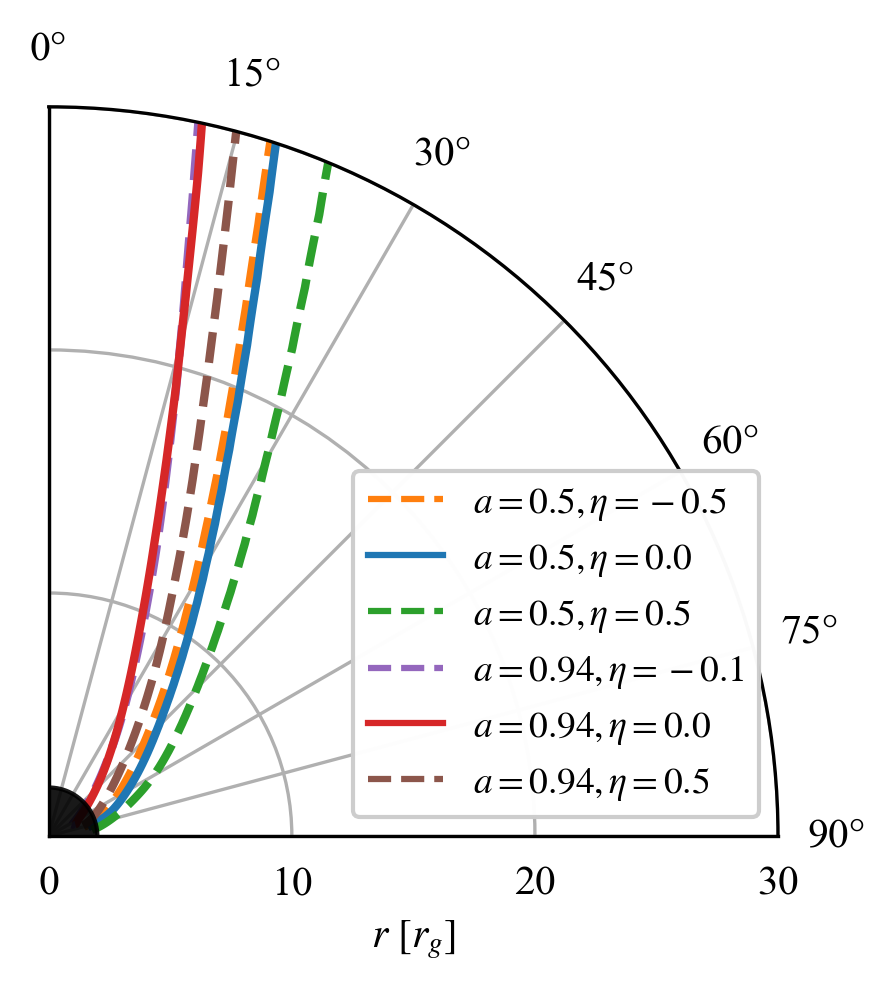

In [29]:
# 将直角坐标(X,Y)转换为极坐标(R,Theta)
def cart2pol(x, y):
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    return r, theta

# Set up polar plot
fig_contour_sigma_polar, ax_contour_sigma_polar = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(3.33, 3.33), dpi=300)

# 对所有6组数据进行坐标转换并绘制
data_sets = [
    # a=0.5系列
    (X_a05ef5, Y_a05ef5, rav_sigma_a05ef5, '#ff7f0e', '--', r'$a=0.5, \eta=-0.5$'),
    (X_a05e00, Y_a05e00, rav_sigma_a05e00, '#1f77b4', '-', r'$a=0.5, \eta=0.0$'),
    (X_a05ez5, Y_a05ez5, rav_sigma_a05ez5, '#2ca02c', '--', r'$a=0.5, \eta=0.5$'),
    # a=0.9系列
    (X_a09ef1, Y_a09ef1, rav_sigma_a09ef1, '#9467bd', '--', r'$a=0.94, \eta=-0.1$'),
    (X_a09e00, Y_a09e00, rav_sigma_a09e00, '#d62728', '-', r'$a=0.94, \eta=0.0$'),
    (X_a09ez5, Y_a09ez5, rav_sigma_a09ez5, '#8c564b', '--', r'$a=0.94, \eta=0.5$')
]

# 绘制所有数据
for X, Y, sigma_data, color, style, label in data_sets:
    R, Theta = cart2pol(X, Y)
    cs = ax_contour_sigma_polar.contour(Theta, R, sigma_data,
                                      levels=[0], colors=color, 
                                      linestyles=style,
                                      linewidths=2)
    # 为图例添加一个空线条
    ax_contour_sigma_polar.plot([], [], color=color, linestyle=style, label=label)

# 添加一个半径为2的黑色圆盘在中心处
circle_radius = 2
theta = np.linspace(0, 2*np.pi, 100)
r = np.ones_like(theta) * circle_radius
ax_contour_sigma_polar.fill(theta, r, color='black', alpha=0.9, zorder=10) #置于最上层

# 添加 y=x^2 的曲线
# 在极坐标中，需要将 y=x^2 转换为极坐标形式
# 对于 y=x^2，可以表示为 r*sin(theta) = (r*cos(theta))^2
# 即 r = cos(theta)/sin(theta)^2 当 sin(theta) != 0
# x_values_19 = np.linspace(0, 50, 1000)
# y_values_19 = x_values_19**2
# # 转换为极坐标
# r_parabola_19 = np.sqrt(x_values_19**2 + y_values_19**2)
# theta_parabola_19 = np.arctan2(y_values_19, x_values_19)
# # 只保留第一象限的部分
# mask = (theta_parabola_19 >= 0) & (theta_parabola_19 <= np.pi/2) & (r_parabola_19 <= 50)
# ax_contour_sigma_polar.plot(theta_parabola_19[mask], r_parabola_19[mask], color='gray', linestyle='-', linewidth=2, label=r'$y=x^{1.9}$')

# x_values_15 = np.linspace(0, 50, 1000)
# y_values_15 = (x_values_15)**1.8
# # 转换为极坐标
# r_parabola_15 = np.sqrt(x_values_15**2 + y_values_15**2)
# theta_parabola_15 = np.arctan2(y_values_15, x_values_15)
# # 只保留第一象限的部分
# mask = (theta_parabola_15 >= 0) & (theta_parabola_15 <= np.pi/2) & (r_parabola_15 <= 50)
# ax_contour_sigma_polar.plot(theta_parabola_15[mask], r_parabola_15[mask], color='gray', linestyle='-', linewidth=2, label=r'$y=x^{1.5}$')


angles = np.array([0, 15/180*np.pi, 30/180*np.pi, 45/180*np.pi, 60/180*np.pi, 75/180*np.pi, 90/180*np.pi])
ax_contour_sigma_polar.set_xticks(angles)
ax_contour_sigma_polar.set_xticklabels(['90°', '75°', '60°', '45°', '30°', '15°', '0°'])

ax_contour_sigma_polar.set_yticks([0, 10, 20, 30])
ax_contour_sigma_polar.set_rlabel_position(0)
ax_contour_sigma_polar.set_xlim(0, 0.5*np.pi)
ax_contour_sigma_polar.set_ylim(0, 30)

# 调整图形布局，为xlabel留出更多空间
fig_contour_sigma_polar.subplots_adjust(bottom=0.15)
ax_contour_sigma_polar.set_xlabel(r'$r~[r_g]$', labelpad=15)
ax_contour_sigma_polar.set_aspect('equal')

# Enable grid
ax_contour_sigma_polar.grid(True)
ax_contour_sigma_polar.legend(ncol=1, fontsize=9, frameon=True, framealpha=0.98, loc='lower right', bbox_to_anchor=(1.0, 0))
# Display the plot
plt.savefig('kz_analysis_result_3d_jet.png', dpi=300)
plt.show()


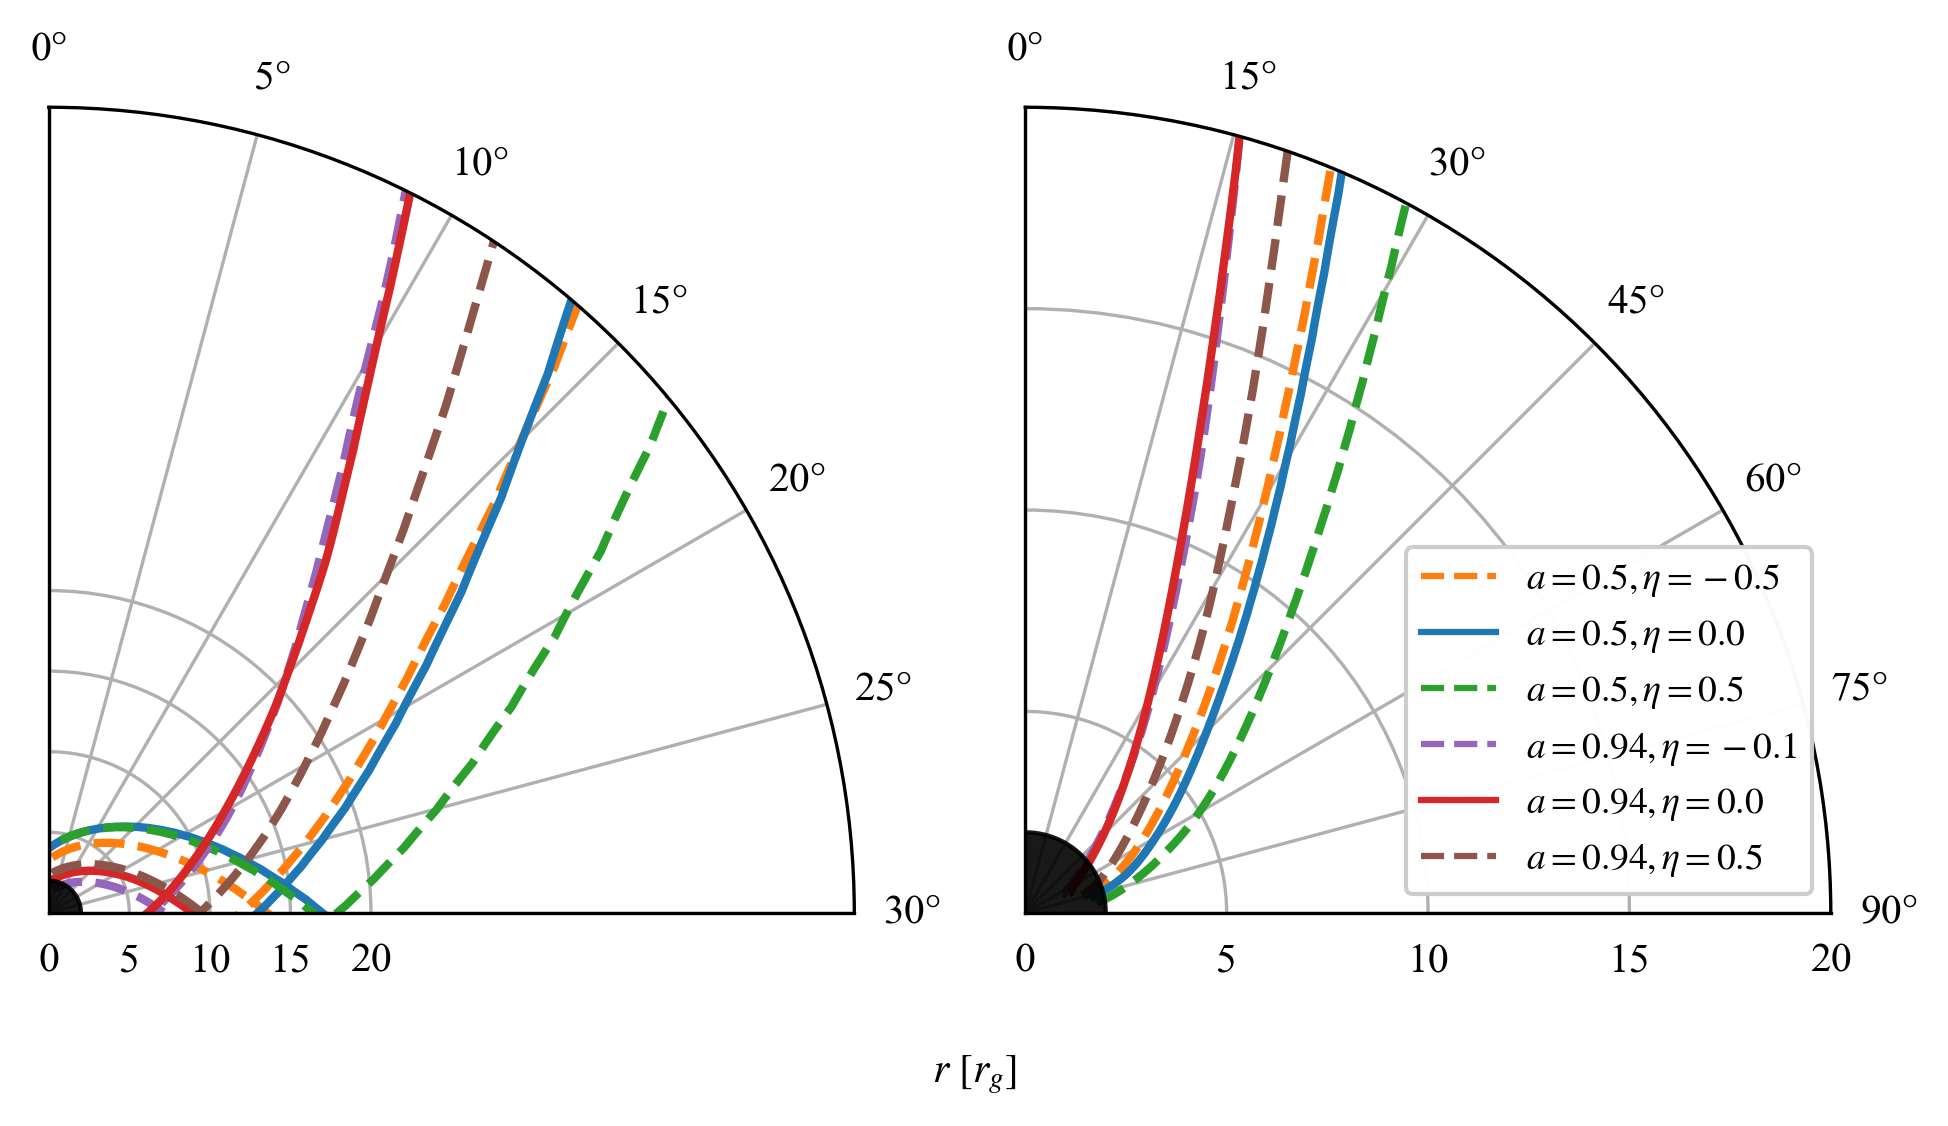

In [18]:
# 将直角坐标(X,Y)转换为极坐标(R,Theta)
def cart2pol(x, y):
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    return r, theta

# 创建一个包含两个子图的图形
fig, (ax_wide, ax_zoom) = plt.subplots(1, 2, subplot_kw={'projection': 'polar'}, figsize=(6.66, 3.6), dpi=300)

# 定义数据集
data_sets = [
    # a=0.5系列
    (X_a05ef5, Y_a05ef5, rav_sigma_a05ef5, '#ff7f0e', '--', r'$a=0.5, \eta=-0.5$'),
    (X_a05e00, Y_a05e00, rav_sigma_a05e00, '#1f77b4', '-', r'$a=0.5, \eta=0.0$'),
    (X_a05ez5, Y_a05ez5, rav_sigma_a05ez5, '#2ca02c', '--', r'$a=0.5, \eta=0.5$'),
    # a=0.9系列
    (X_a09ef1, Y_a09ef1, rav_sigma_a09ef1, '#9467bd', '--', r'$a=0.94, \eta=-0.1$'),
    (X_a09e00, Y_a09e00, rav_sigma_a09e00, '#d62728', '-', r'$a=0.94, \eta=0.0$'),
    (X_a09ez5, Y_a09ez5, rav_sigma_a09ez5, '#8c564b', '--', r'$a=0.94, \eta=0.5$')
]

# 在两个子图中绘制相同的数据
for i, (ax, r_max) in enumerate(zip([ax_wide, ax_zoom], [50, 20])):
    # 绘制所有数据
    for X, Y, sigma_data, color, style, label in data_sets:
        R, Theta = cart2pol(X, Y)
        
        if i == 0:  # 左图 - 对角度进行缩放，将0-30度区间放大到0-90度
            # 只选择0-30度范围内的数据
            # mask = (Theta >= np.pi/2 - np.pi/6) & (Theta <= np.pi/2)
            # 对角度进行缩放：将60-90度(π/3-π/2)映射到0-90度(0-π/2)
            scaled_theta = (Theta - (np.pi/2 - np.pi/6)) * 3
            cs = ax.contour(scaled_theta, R, sigma_data,
                          levels=[0], colors=color, 
                          linestyles=style,
                          linewidths=2)
        else:  # 右图 - 保持原始角度
            cs = ax.contour(Theta, R, sigma_data,
                          levels=[0], colors=color, 
                          linestyles=style,
                          linewidths=2)
            
        # 为图例添加一个空线条
        ax.plot([], [], color=color, linestyle=style, label=label)

    # 添加一个半径为2的黑色圆盘在中心处
    circle_radius = 2
    theta = np.linspace(0, 2*np.pi, 100)
    r = np.ones_like(theta) * circle_radius
    ax.fill(theta, r, color='black', alpha=0.9, zorder=10) #置于最上层

    # 设置角度范围和刻度
    if i == 0:  # 左图 - 0到90度区间，但实际对应原始数据的60到90度
        ax.set_xlim(0, 0.5*np.pi)
        angles = np.linspace(0, 0.5*np.pi, 7)  # 均匀分布7个刻度
        ax.set_xticks(angles)
        # 刻度标签从30度到0度
        degree_labels = [f"{int(30-(i*30/6))}°" for i in range(7)]
        ax.set_xticklabels(degree_labels)
    else:  # 右图 - 保持原来的0到90度区间
        ax.set_xlim(0, 0.5*np.pi)
        angles = np.array([0, 15/180*np.pi, 30/180*np.pi, 45/180*np.pi, 60/180*np.pi, 75/180*np.pi, 90/180*np.pi])
        ax.set_xticks(angles)
        ax.set_xticklabels(['90°', '75°', '60°', '45°', '30°', '15°', '0°'])

    # 设置半径刻度和范围
    if r_max == 80:
        ax.set_yticks([0, 50, 100])
        # ax.set_title('大尺度视图')
    else:
        ax.set_yticks([0, 5, 10, 15, 20])
        # ax.set_title('局部放大视图')
    
    ax.set_rlabel_position(0)
    ax.set_ylim(0, r_max)
    ax.set_aspect('equal')
    ax.grid(True)

# 为右侧图添加图例
ax_zoom.legend(ncol=1, fontsize=9, frameon=True, framealpha=0.98, loc='lower right', bbox_to_anchor=(1.0, 0))

# 调整布局
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)  # 调整底部边距，为xlabel留出空间

# 添加共享的x轴标签
fig.text(0.5, 0.05, r'$r~[r_g]$', ha='center', va='center')

# 显示图像
plt.show()
